In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

In [3]:
# load dataset
df=pd.read_csv('C:\Shopper Spectrum\online_retail.csv')
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\PRATHAP\AppData\Local\Temp\ipykernel_8576\2904812642.py:2: SyntaxWarning: invalid escape sequence '\S'
  df=pd.read_csv('C:\Shopper Spectrum\online_retail.csv')


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [4]:
#change date column to right datetime format: 
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   TotalSpend   392692 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 43.8 MB


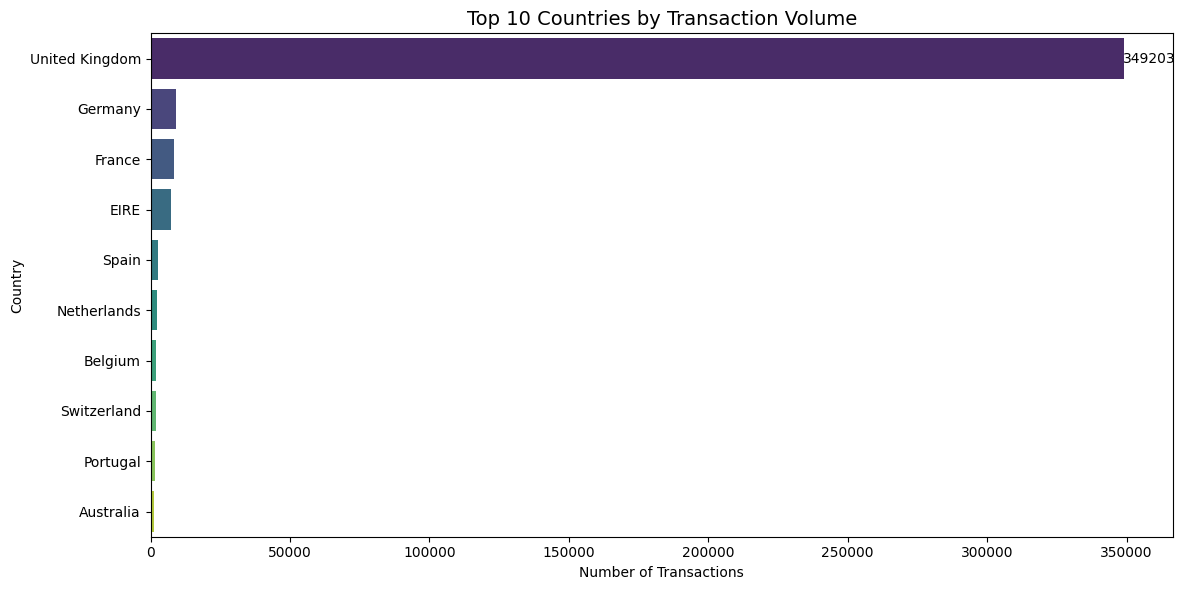

In [6]:
#1 Analyze transaction volume by country:

plt.figure(figsize=(12, 6))
country_counts = df['Country'].value_counts().head(10)
ax = sns.barplot(x=country_counts.values, y=country_counts.index, hue=country_counts.index, palette='viridis', legend=False)
ax.bar_label(ax.containers[0], padding=-1)
plt.title('Top 10 Countries by Transaction Volume', fontsize=14)
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

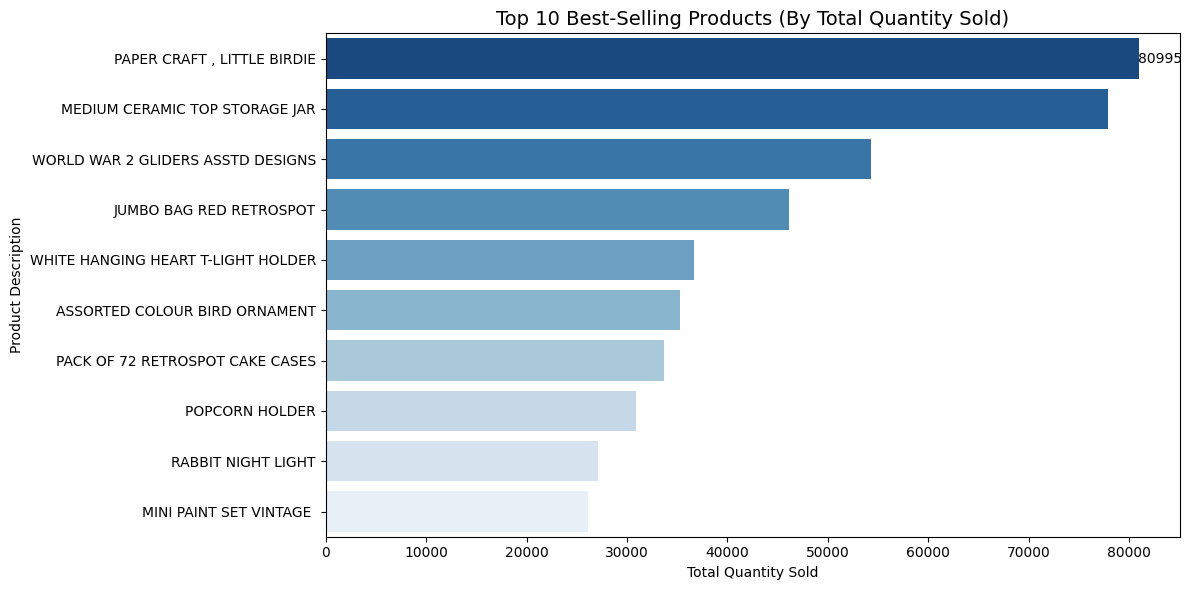

In [7]:
#2 Identify top-selling products
plt.figure(figsize=(12, 6))
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
ax = sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='Blues_r', legend=False)
ax.bar_label(ax.containers[0], padding=-1)

plt.title('Top 10 Best-Selling Products (By Total Quantity Sold)', fontsize=14)
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

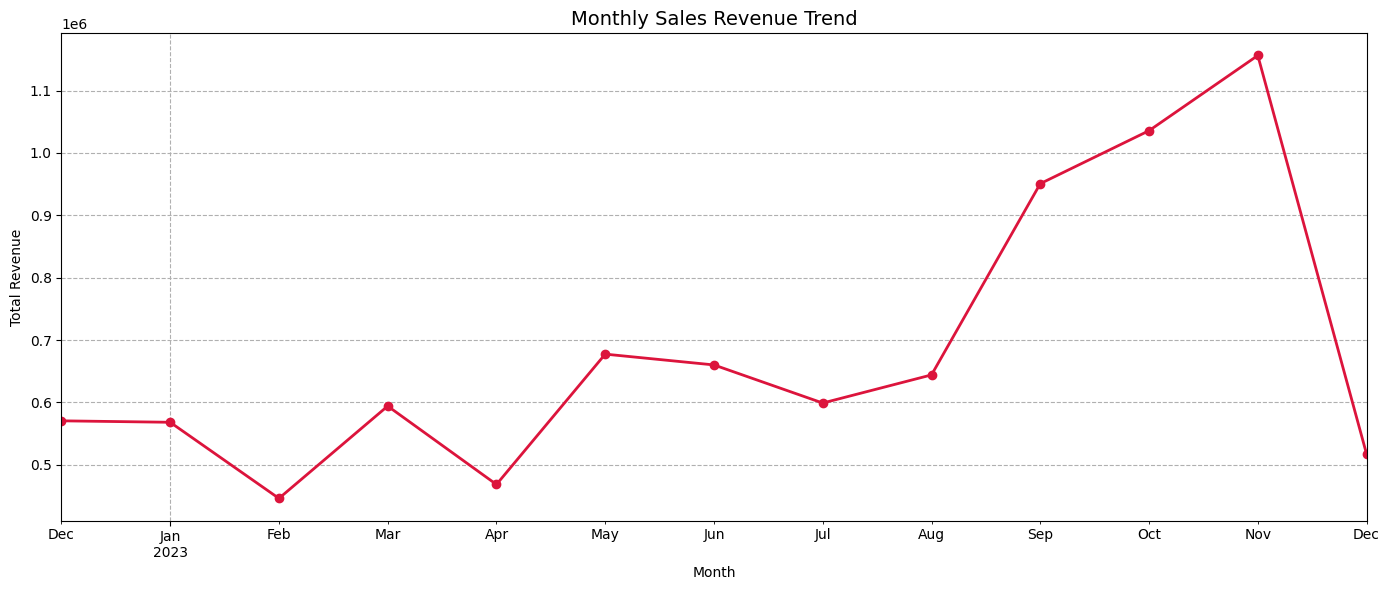

In [8]:
#3 Visualize purchase trends over time:
# Extract Month and Year for trend analysis
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('InvoiceMonth')['TotalSpend'].sum()

plt.figure(figsize=(14, 6))
monthly_sales.plot(kind='line', marker='o', color='crimson', linewidth=2)
plt.title('Monthly Sales Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

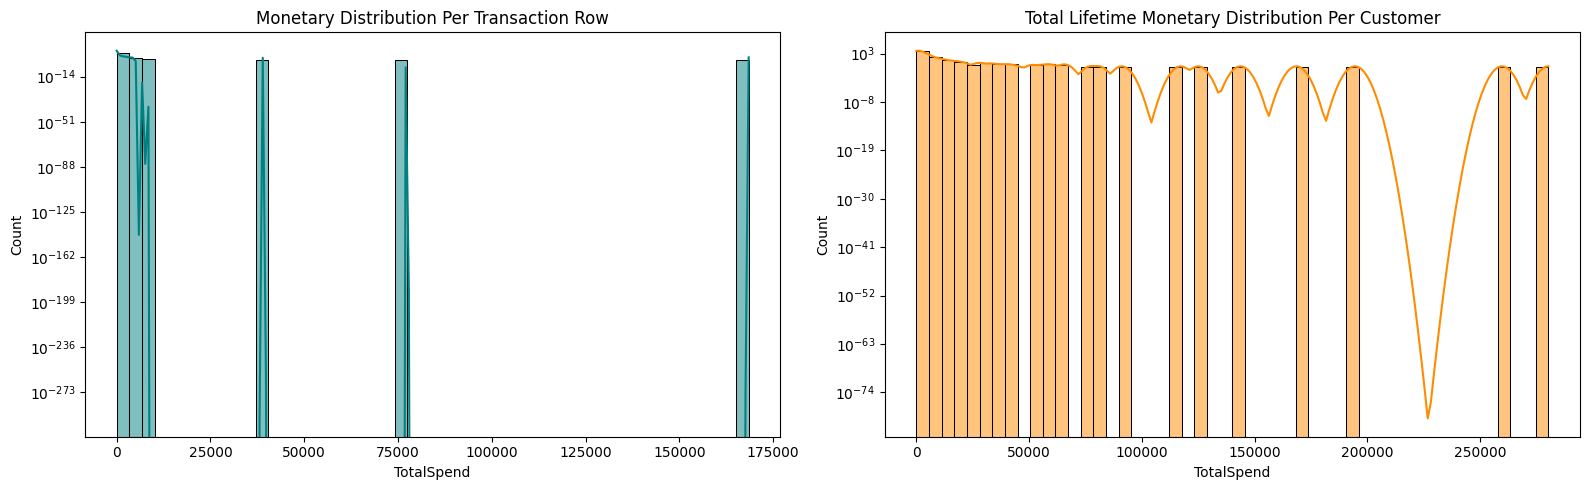

In [9]:
#4 Inspect monetary distribution per transaction and customer:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Per Transaction Distribution
sns.histplot(df['TotalSpend'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Monetary Distribution Per Transaction Row')
axes[0].set_yscale('log') # Log scale helps handle extreme outliers visually

# Per Customer Distribution
customer_monetary = df.groupby('CustomerID')['TotalSpend'].sum()
sns.histplot(customer_monetary, bins=50, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Total Lifetime Monetary Distribution Per Customer')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

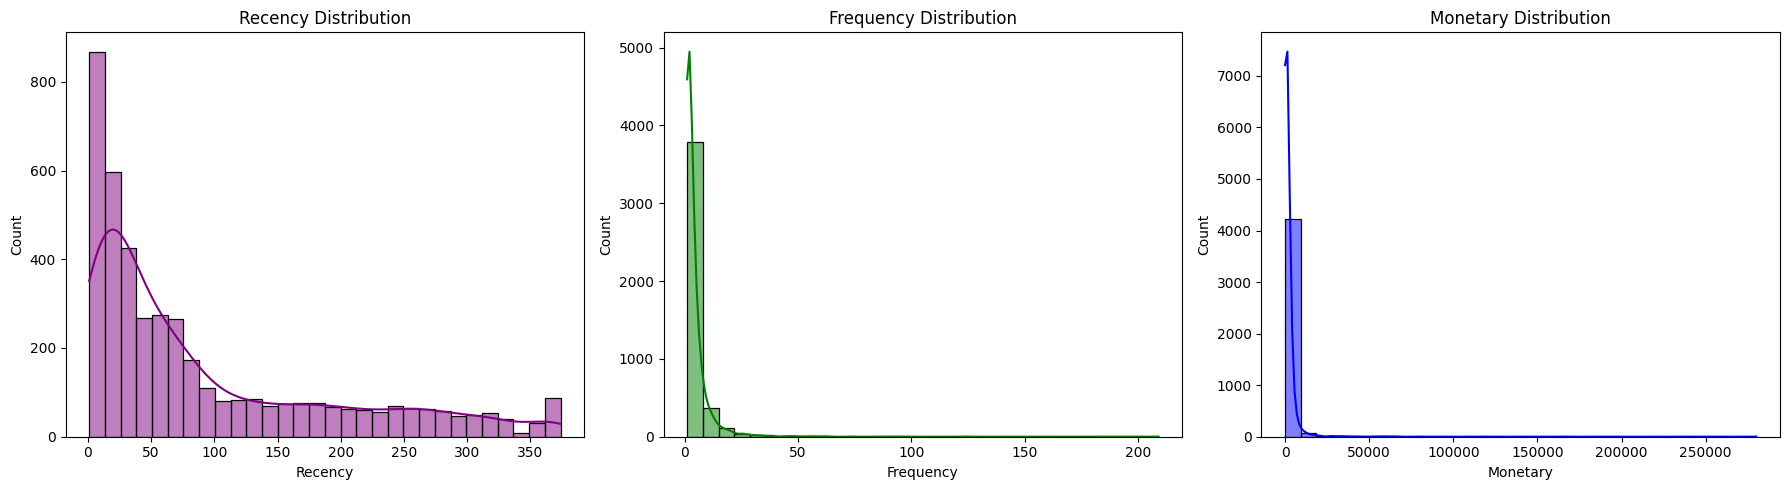

In [10]:
#5 RFM distributions:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by Customer to create RFM Features
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, 
    'InvoiceNo': 'nunique',                                  
    'TotalSpend': 'sum'                                      
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Visualize Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0], color='purple').set_title('Recency Distribution')
sns.histplot(rfm['Frequency'], bins=30, kde=True, ax=axes[1], color='g').set_title('Frequency Distribution')
sns.histplot(rfm['Monetary'], bins=30, kde=True, ax=axes[2], color='b').set_title('Monetary Distribution')
plt.tight_layout()
plt.show()

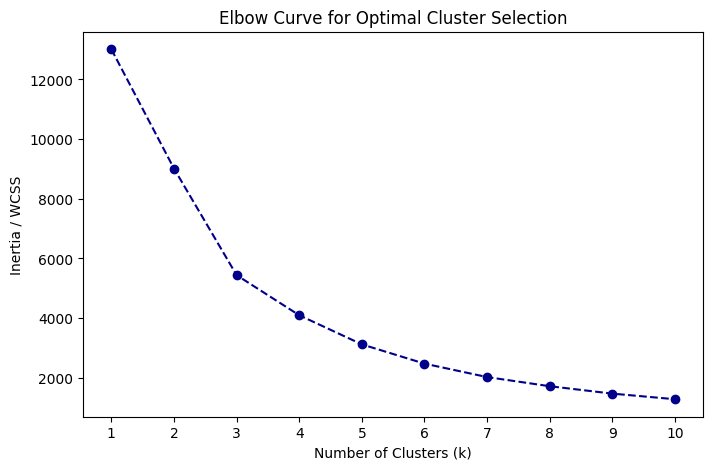

In [11]:
#6 Elbow curve for cluster selection:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Scale features since K-Means uses Euclidean distance
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# 2. Compute Inertia for varying cluster numbers
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# 3. Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='darkblue')
plt.title('Elbow Curve for Optimal Cluster Selection')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia / WCSS')
plt.xticks(k_range)
plt.show()


--- Customer Cluster Profiles ---
        Recency Frequency  Monetary      
           mean      mean      mean count
Cluster                                  
0          43.7       3.7    1353.6  3054
1         248.1       1.6     478.8  1067
2           7.4      82.5  127188.0    13
3          15.5      22.3   12690.5   204


C:\Users\PRATHAP\AppData\Local\Temp\ipykernel_8576\720955539.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Monetary', data=rfm, ax=axes[0], palette='Set2')


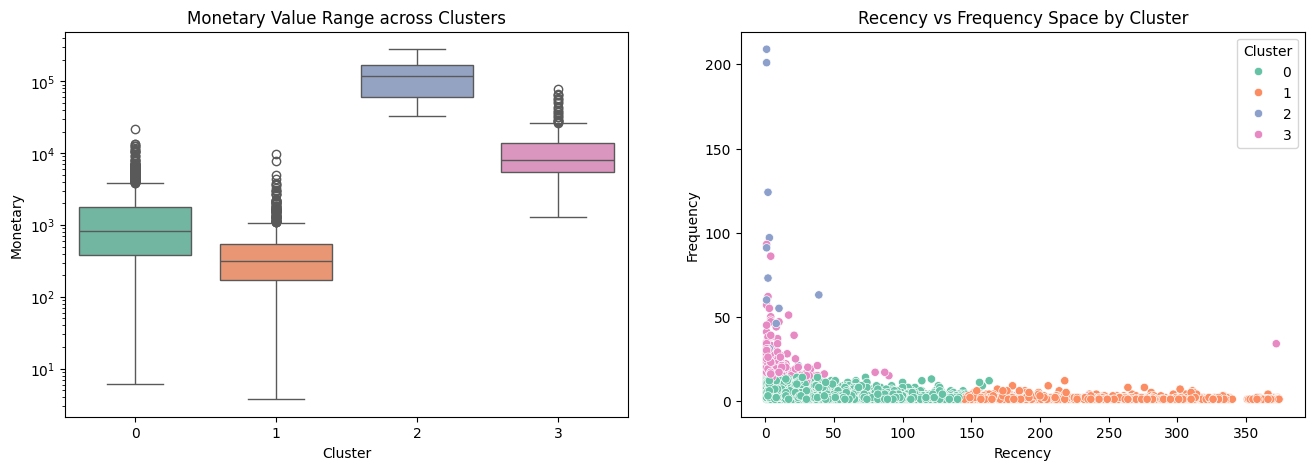

In [12]:
#7 Customer cluster profiles

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# View average RFM profiles across clusters
cluster_profiles = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

print("--- Customer Cluster Profiles ---")
print(cluster_profiles)

# Visualizing Cluster Sizes and Metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(x='Cluster', y='Monetary', data=rfm, ax=axes[0], palette='Set2')
axes[0].set_title('Monetary Value Range across Clusters')
axes[0].set_yscale('log')

sns.scatterplot(x='Recency', y='Frequency', hue='Cluster', data=rfm, ax=axes[1], palette='Set2')
axes[1].set_title('Recency vs Frequency Space by Cluster')
plt.show()

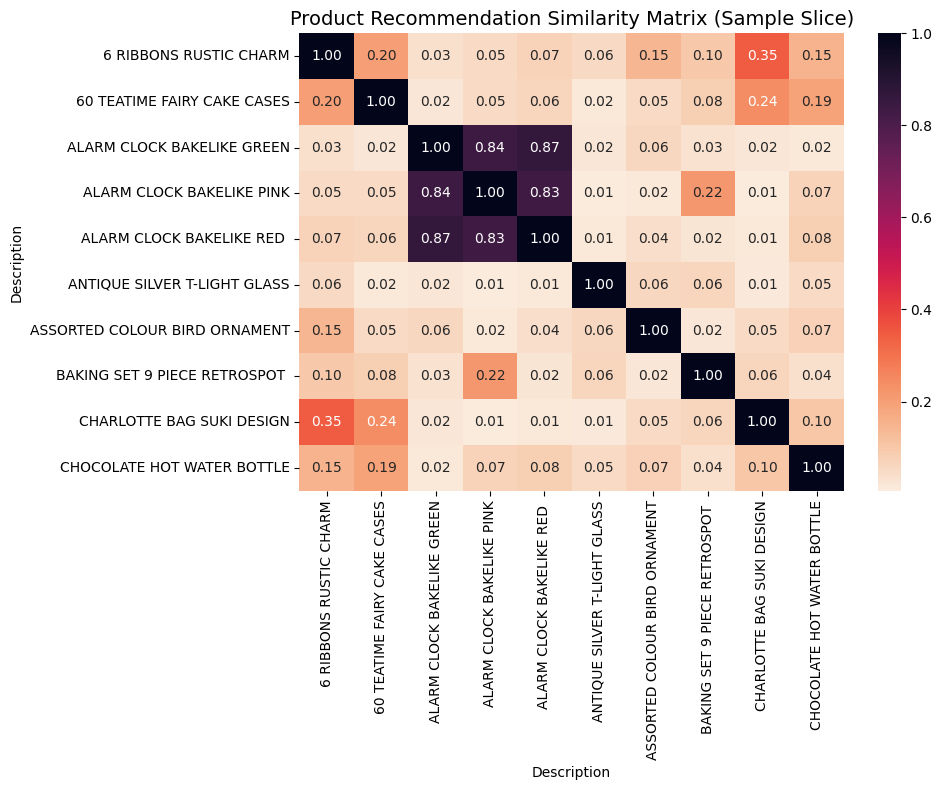

In [13]:
#8 Product recommendation heatmap / similarity matrix:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Group data to find quantities per product for each customer
# Taking top 100 products for performance visualization purposes in the heatmap
top_100_items = df['Description'].value_counts().head(100).index
df_subset = df[df['Description'].isin(top_100_items)]

pivot_matrix = df_subset.pivot_table(index='Description', columns='CustomerID', values='Quantity', aggfunc='sum').fillna(0)

# 2. Compute Cosine Similarity between items
item_similarity = cosine_similarity(pivot_matrix)
item_sim_df = pd.DataFrame(item_similarity, index=pivot_matrix.index, columns=pivot_matrix.index)

# 3. Display top 10x10 slice of item similarity as a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(item_sim_df.iloc[:10, :10], annot=True, cmap='rocket_r', fmt=".2f")
plt.title('Product Recommendation Similarity Matrix (Sample Slice)', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\PRATHAP\AppData\Local\Temp\ipykernel_8576\1632979119.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Description', y='Total_Quantity', data=chart_data, ax=axes[0], palette='Blues_r')
C:\Users\PRATHAP\AppData\Local\Temp\ipykernel_8576\1632979119.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Paper Craft', 'White Heart Holder'])
C:\Users\PRATHAP\AppData\Local\Temp\ipykernel_8576\1632979119.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Description', y='Transaction_Count', data=chart_data, ax=axes[1], palette='Oranges_r')
C:\Users\PRATHAP\AppData\Local\

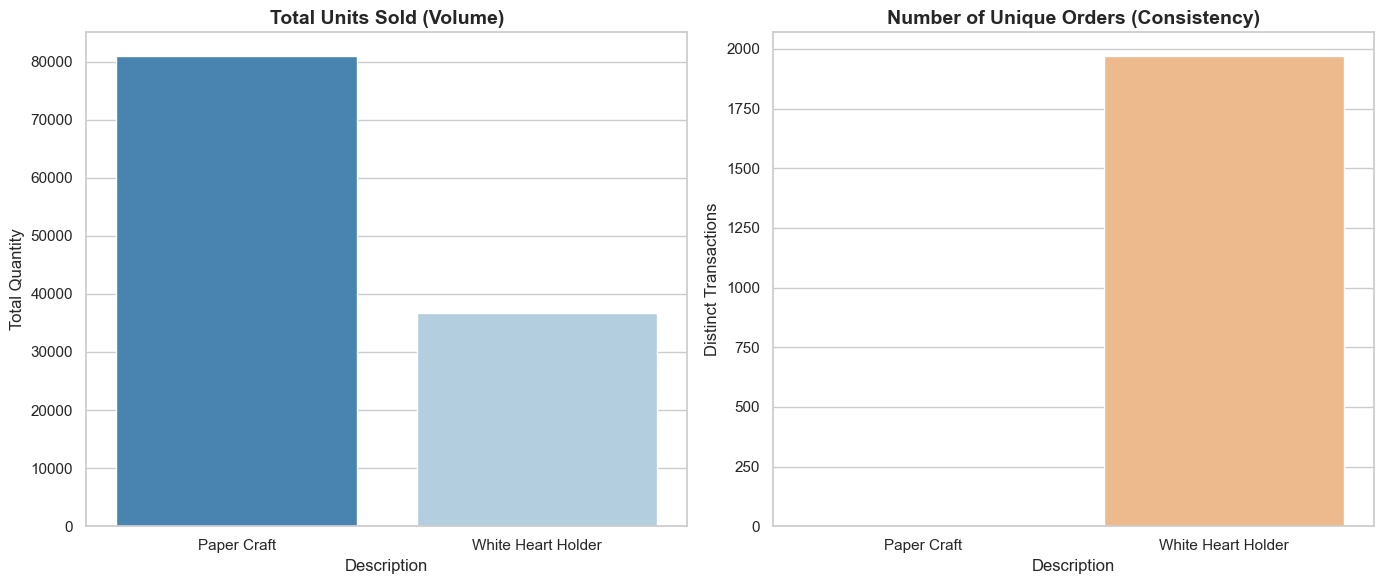

In [15]:
#find which product sell's the most volume and quantity:

# 1. Filter data for just these two items
target_items = df[df['Description'].isin(['PAPER CRAFT , LITTLE BIRDIE', 'WHITE HANGING HEART T-LIGHT HOLDER'])]

# 2. Calculate Total Quantity and Unique Transaction Counts
chart_data = target_items.groupby('Description').agg(
    Total_Quantity=('Quantity', 'sum'),
    Transaction_Count=('InvoiceNo', 'nunique')
).reset_index()

# 3. Plot the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Left Plot: Total Quantity
sns.barplot(x='Description', y='Total_Quantity', data=chart_data, ax=axes[0], palette='Blues_r')
axes[0].set_title('Total Units Sold (Volume)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Quantity')
axes[0].set_xticklabels(['Paper Craft', 'White Heart Holder'])

# Right Plot: Transaction Count
sns.barplot(x='Description', y='Transaction_Count', data=chart_data, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Number of Unique Orders (Consistency)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Distinct Transactions')
axes[1].set_xticklabels(['Paper Craft', 'White Heart Holder'])

plt.tight_layout()
plt.savefig('models/volume_vs_consistency.png', dpi=300)
plt.show()